In [1]:
# load all useful libraries  

import pandas as pd
import matplotlib.pyplot as plt

import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split

from pytorch_tabnet.tab_model import TabNetRegressor

In [2]:
# just useful plotting stuff  
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Serif",
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    'figure.dpi': 125
})

In [3]:
# read data 
sig_df = pd.read_csv('data/Jewel.csv')
bg_df = pd.read_csv('data/Pythia.csv')
herwig_df = pd.read_csv('data/Herwig.csv')
hydrocolbt_df = pd.read_csv('data/CoLBTHydro.csv')

In [4]:
# organize signal and background samples 
sig_X = sig_df.dropna().iloc[:,0:-1].values
sig_Y = sig_df.dropna().iloc[:,-1].values

bg_X = bg_df.dropna().iloc[:,0:-1].values
bg_Y = bg_df.dropna().iloc[:,-1].values

herwig_X = herwig_df.dropna().iloc[:,0:-1].values
herwig_Y = herwig_df.dropna().iloc[:,-1].values

hydrocolbt_X = hydrocolbt_df.dropna().iloc[:,0:-1].values
hydrocolbt_Y = hydrocolbt_df.dropna().iloc[:,-1].values

In [5]:
sig_X_train, sig_X_test, sig_Y_train, sig_Y_test = train_test_split(sig_X, sig_Y, train_size=0.9, shuffle=False)
bg_X_train, bg_X_test, bg_Y_train, bg_Y_test = train_test_split(bg_X, bg_Y, train_size=0.9, shuffle=False)
herwig_X_train, herwig_X_test, herwig_Y_train, herwig_Y_test = train_test_split(herwig_X, herwig_Y, train_size=0.9, shuffle=False)
hydrocolbt_X_train, hydrocolbt_X_test, hydrocolbt_Y_train, hydrocolbt_Y_test = train_test_split(hydrocolbt_X, hydrocolbt_Y, train_size=0.9, shuffle=False)

In [6]:
X_test = np.concatenate((sig_X_test, bg_X_test, herwig_X_test, hydrocolbt_X_test), axis=0)
Y_test = np.concatenate((sig_Y_test, bg_Y_test, herwig_Y_test, hydrocolbt_Y_test), axis=0)

In [7]:
# load the existing pre-trained that you did! 
model = TabNetRegressor()
model.load_model('model/test_model.zip')

/opt/anaconda3/envs/work_py_ml/lib/python3.11/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


In [20]:
# this is the trained model from the paper 
model_old = TabNetRegressor()
model_old.load_model('model/model.zip')

/opt/anaconda3/envs/work_py_ml/lib/python3.11/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


In [21]:
SIG_out = model_old.predict(sig_X_test)
BG_out = model_old.predict(bg_X_test)
herwig_out = model_old.predict(herwig_X_test)
hydrocolbt_out = model_old.predict(hydrocolbt_X_test)

In [22]:
SIG_out_ = np.where(SIG_out < 0, 0, SIG_out)
SIG_out_ = np.where(SIG_out_ > 1, 1, SIG_out_)
BG_out_ = np.where(BG_out < 0, 0, BG_out)
BG_out_ = np.where(BG_out_ > 1, 1, BG_out_)
herwig_out_ = np.where(herwig_out < 0, 0, herwig_out)
herwig_out_ = np.where(herwig_out_ > 1, 1, herwig_out_)
hydrocolbt_out_ = np.where(hydrocolbt_out < 0, 0, hydrocolbt_out)
hydrocolbt_out_ = np.where(hydrocolbt_out_ > 1, 1, hydrocolbt_out_)

In [11]:
bins = np.linspace(0, 1, 51)

In [15]:
# this is just to fix the latex issues 
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = False

(array([1.22017847, 0.28228009, 0.20943362, 0.74667638, 0.81041705,
        0.88781643, 0.35512657, 0.36878529, 0.42342014, 0.51903114,
        0.97887452, 1.27026043, 1.61172828, 1.49335276, 1.34765981,
        1.26570752, 1.338554  , 1.33400109, 1.338554  , 1.338554  ,
        1.2474959 , 1.13367328, 1.06993262, 1.21562557, 1.1518849 ,
        1.33400109, 1.13822619, 1.3431069 , 1.27936624, 1.23839009,
        1.39774176, 1.46148243, 1.34765981, 1.46603533, 1.38408304,
        1.11546166, 0.85594609, 0.78765252, 0.84684028, 0.83318157,
        0.78309962, 0.82407576, 0.67838281, 0.85139319, 0.86960481,
        0.92879257, 1.17464943, 0.87415771, 0.17301038, 0.05463486]),
 array([0.  , 0.02, 0.04, 0.06, 0.08, 0.1 , 0.12, 0.14, 0.16, 0.18, 0.2 ,
        0.22, 0.24, 0.26, 0.28, 0.3 , 0.32, 0.34, 0.36, 0.38, 0.4 , 0.42,
        0.44, 0.46, 0.48, 0.5 , 0.52, 0.54, 0.56, 0.58, 0.6 , 0.62, 0.64,
        0.66, 0.68, 0.7 , 0.72, 0.74, 0.76, 0.78, 0.8 , 0.82, 0.84, 0.86,
        0.88, 0.9 , 0.

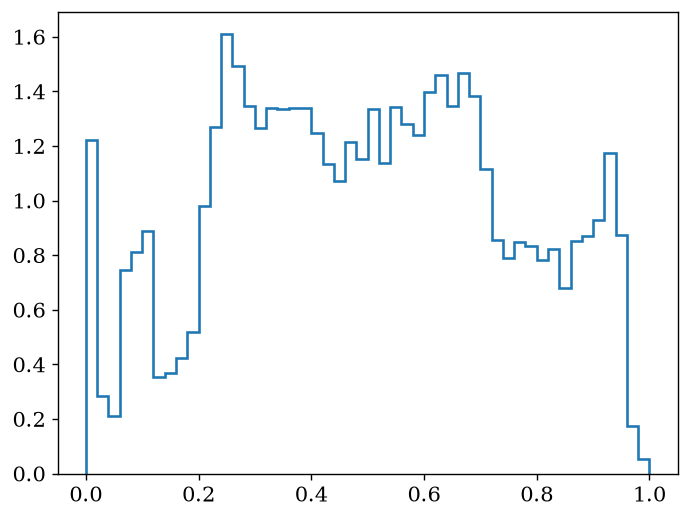

In [16]:
# this is the histogram of the model output for a given input. 
plt.hist(SIG_out_, bins, histtype='step', alpha=1, density=True, stacked=True, label="jewel", fill=False, linewidth=1.5)

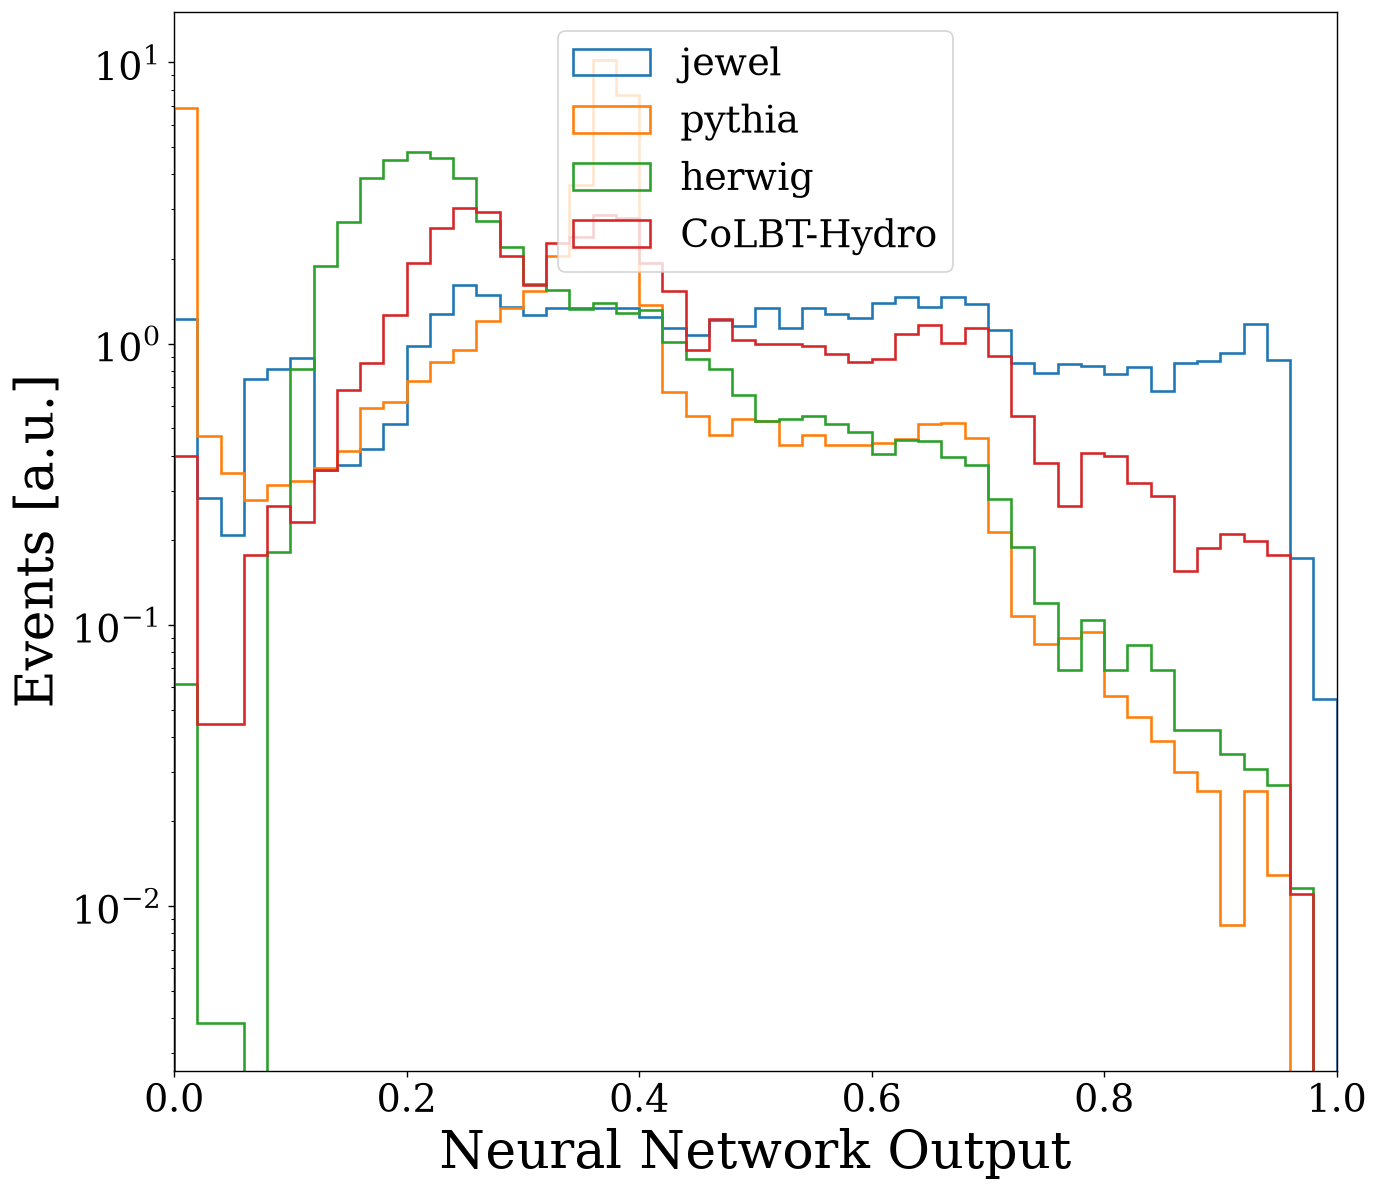

In [17]:
fig, ax = plt.subplots(1, figsize=(12,11))
plt.hist(SIG_out_, bins, histtype='step', alpha=1, density=True, stacked=True, label="jewel", fill=False, linewidth=1.5)
plt.hist(BG_out_, bins, histtype='step', alpha=1, density=True, stacked=True, label="pythia", linewidth=1.5)
plt.hist(herwig_out_, bins, histtype='step', alpha=1, density=True, stacked=True, label="herwig", linewidth=1.5)
plt.hist(hydrocolbt_out_, bins, histtype='step', alpha=1, density=True, stacked=True, label="CoLBT-Hydro", linewidth=1.5)
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)
plt.legend(loc='upper center', fontsize=22)
plt.xlim([0, 1])
# plt.ylim([1e-2, 100])
plt.xlabel("Neural Network Output", fontsize=30)
plt.ylabel("Events [a.u.]", fontsize=30)
plt.yscale('log')
plt.savefig(f'hist.pdf', dpi=400,bbox_inches='tight')

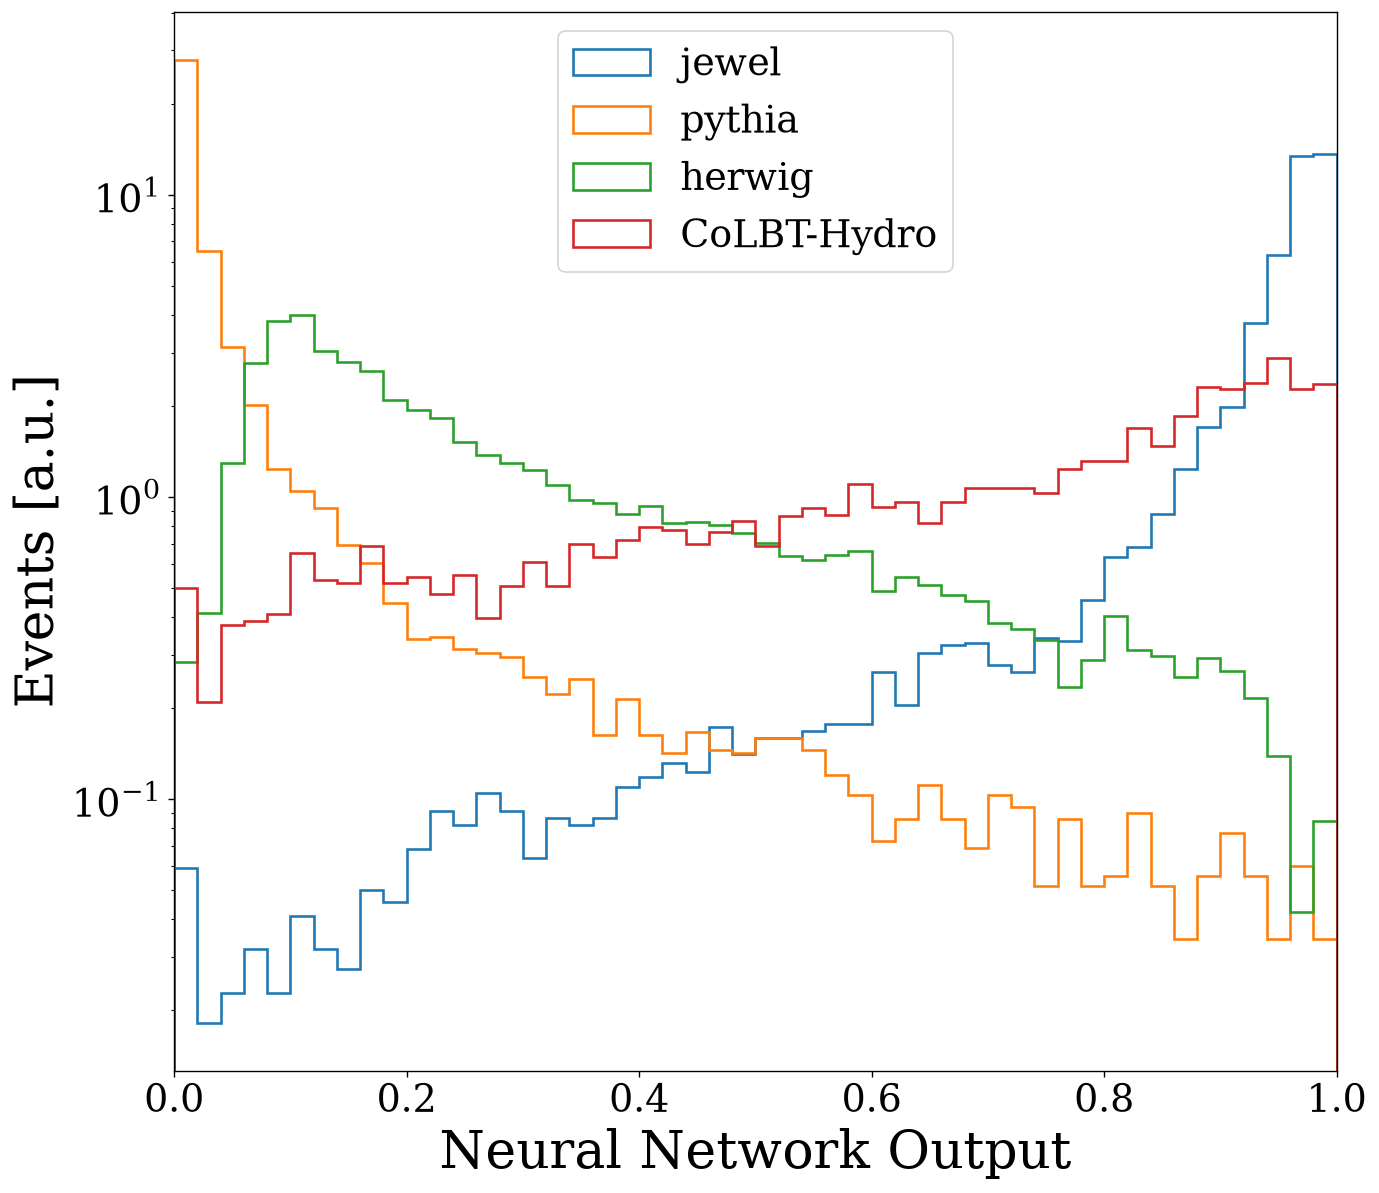

In [23]:
fig, ax = plt.subplots(1, figsize=(12,11))
plt.hist(SIG_out_, bins, histtype='step', alpha=1, density=True, stacked=True, label="jewel", fill=False, linewidth=1.5)
plt.hist(BG_out_, bins, histtype='step', alpha=1, density=True, stacked=True, label="pythia", linewidth=1.5)
plt.hist(herwig_out_, bins, histtype='step', alpha=1, density=True, stacked=True, label="herwig", linewidth=1.5)
plt.hist(hydrocolbt_out_, bins, histtype='step', alpha=1, density=True, stacked=True, label="CoLBT-Hydro", linewidth=1.5)
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)
plt.legend(loc='upper center', fontsize=22)
plt.xlim([0, 1])
# plt.ylim([1e-2, 100])
plt.xlabel("Neural Network Output", fontsize=30)
plt.ylabel("Events [a.u.]", fontsize=30)
plt.yscale('log')
plt.savefig(f'hist_old.pdf', dpi=400,bbox_inches='tight')

In [27]:


fpr, tpr, thresholds = roc_curve(Y_test, model_old.predict(X_test))
auc_ = auc(fpr, tpr)



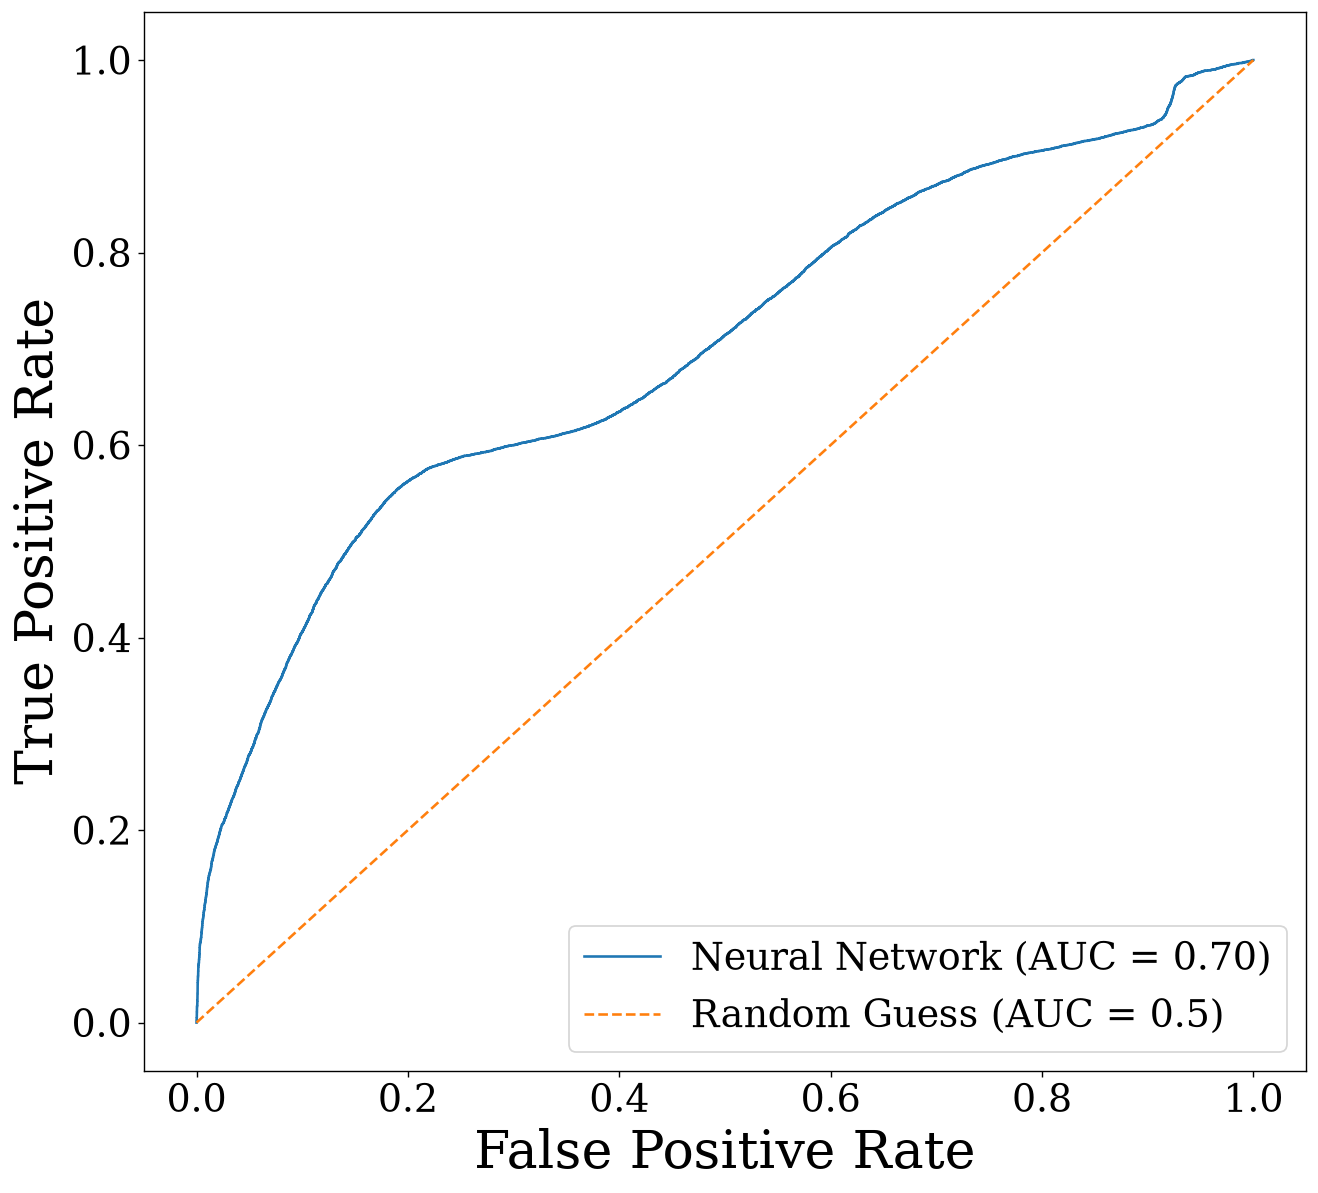

In [19]:
fig, ax = plt.subplots(1, figsize=(12,11))
plt.plot(fpr, tpr, label=f"Neural Network (AUC = {auc_:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Guess (AUC = 0.5)')
plt.xticks(fontsize=22)
# plt.grid(True)
plt.yticks(fontsize=22)
plt.legend(loc="lower right", fontsize=22)
ax.set_ylabel('True Positive Rate', fontsize=30)
ax.set_xlabel('False Positive Rate', fontsize=30)
plt.savefig('roc_curve.pdf', dpi=400,bbox_inches='tight')

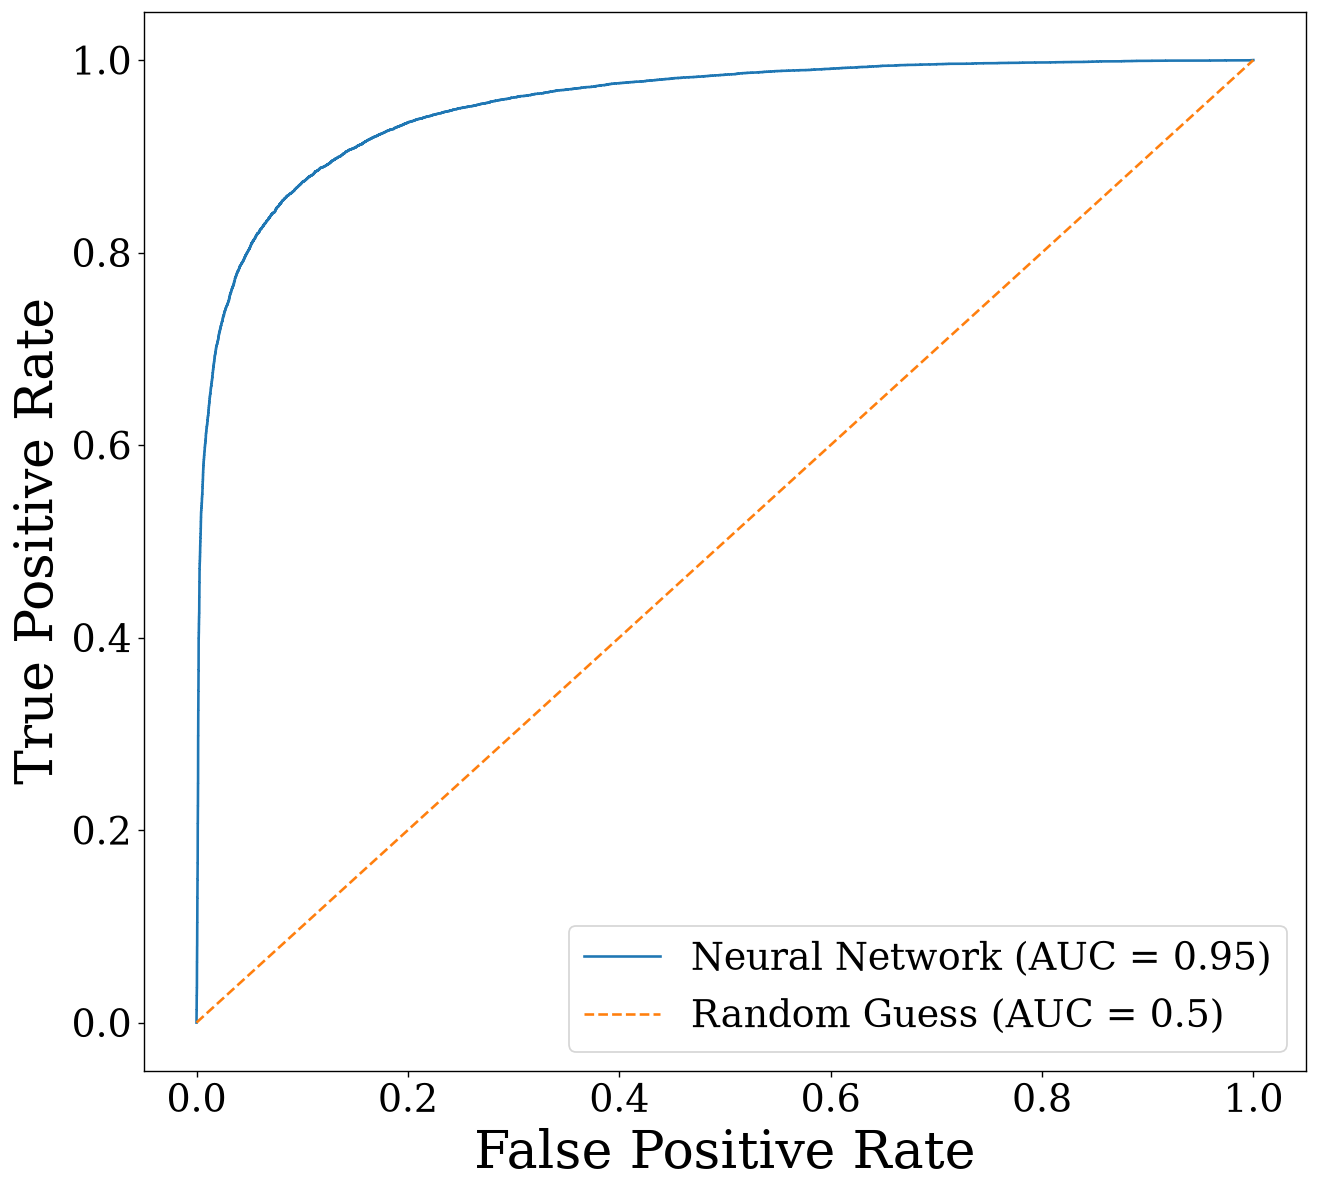

In [28]:
fig, ax = plt.subplots(1, figsize=(12,11))
plt.plot(fpr, tpr, label=f"Neural Network (AUC = {auc_:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Guess (AUC = 0.5)')
plt.xticks(fontsize=22)
# plt.grid(True)
plt.yticks(fontsize=22)
plt.legend(loc="lower right", fontsize=22)
ax.set_ylabel('True Positive Rate', fontsize=30)
ax.set_xlabel('False Positive Rate', fontsize=30)
plt.savefig('roc_curve_old.pdf', dpi=400,bbox_inches='tight')